In [20]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from sklearn.datasets import make_swiss_roll
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *
from finsler_embedding.utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
N = 2000
noise = 0.1
beta=0.9
K = 400
function_type = "coordinates"

m=2
X, t = make_swiss_roll(n_samples=N, noise=noise)
X = torch.from_numpy(X).float()

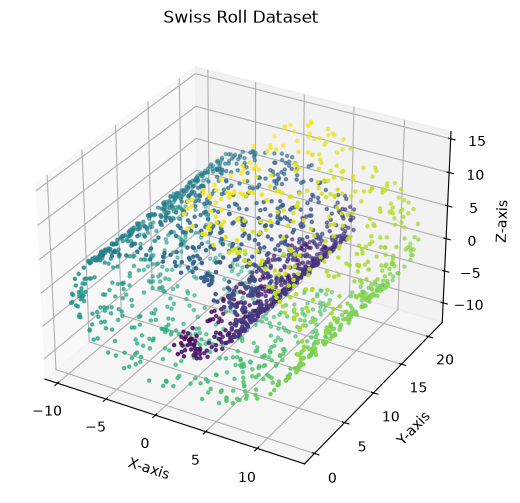

In [22]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax.set_title("Swiss Roll Dataset")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.show()

Text(0.5, 1.0, 'Swiss Roll Dataset (2D Projection)')

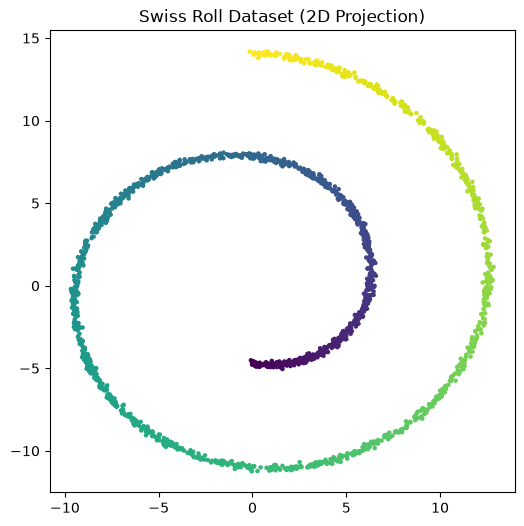

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax.set_title("Swiss Roll Dataset (2D Projection)")

In [24]:
base_cometric = IdentityCoMetric()
# base_cometric = CentroidsCometric(centroids=X, cometric_centroids=base_cometric(X))
omega_true = get_omega("swiss_roll", cometric=base_cometric,dim=3)
# omega_true = get_omega("swiss_roll_normal", cometric=base_cometric,dim=3)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=beta,
)
omega_true

OmegaSwissRoll(
  (cometric): IdentityCoMetric(coscale=1)
)

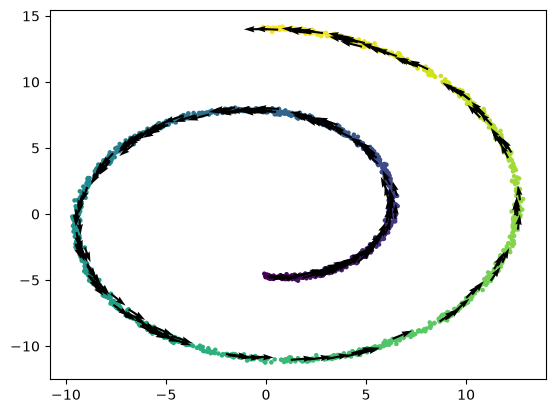

In [25]:

omega_x = omega_true(X)

skip=10
plt.scatter(X.detach()[:, 0], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
plt.quiver(X.detach()[::skip, 0], X.detach()[::skip, 2], omega_x.detach()[::skip, 0], omega_x.detach()[::skip, 2], 
           angles='xy', scale_units='xy')

In [26]:
b_true = randers_metric.omega(X) * randers_metric.beta
v_true = b_to_v(b_true, base_cometric.cometric_tensor(X)).detach()
v_true_norm = v_true.norm(dim=1)

In [27]:
edges = get_knn_graph(X, n_neighbors=10,device="cpu")
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True)


[2026-09-21 11:27:10] - INFO - Found 23116 edges in the KNN graph.


Computing Randers distances: 100%|██████████| 232/232 [00:00<00:00, 4065.81it/s]


In [32]:
epsilon = compute_epsilon_empirical(dst_edges,scale=0.1)

W, _, _ = gaussian_kernel(edges, dst_edges, epsilon, N, m)

Q_inv_theta = get_Q_inv_theta(W, theta=1)
W_theta_s, W_theta_a = get_W_thetas(W, Q_inv_theta)
P_theta_s, P_theta_a = construct_P_thetas(W_theta_s, W_theta_a)
L_theta_s = 1 / epsilon**2 * P_theta_s
L_theta_a = 1 / epsilon * P_theta_a

# Carré du champs

In [33]:
from sklearn.manifold import Isomap
X_low = Isomap(n_components=2, n_neighbors=10).fit_transform(X)
X_low = torch.from_numpy(X_low).float()
bounds = get_bounds(X_low,margin=0.1)
bounds

tensor([-47.7180,  64.4748, -13.9455,  14.8580])

In [34]:
m=2
c_2, C, kappa = randers_constants(m, "gaussian")
Gamma = carre_du_champ(L_theta_s, X_low)
V = L_theta_a @ X_low
Gamma_pinv = truncated_pinv(Gamma, rank=m)
c_norm_sq = kappa * torch.einsum("nij,ni,nj->n", Gamma_pinv, V, V)
admissible = c_norm_sq < 1.0 / (m + 3)

c_tilde = (kappa ** 0.5) * V
H_tilde_inv = Gamma - (m + 2) * kappa * torch.einsum("ni,nj->nij", V, V)
H_tilde = truncated_pinv(H_tilde_inv, rank=m)
lambda_tilde = 1.0 - torch.einsum("nij,ni,nj->n", H_tilde, c_tilde, c_tilde)

V_norm = V / (c_norm_sq.sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

Number of non admissible points: 1794


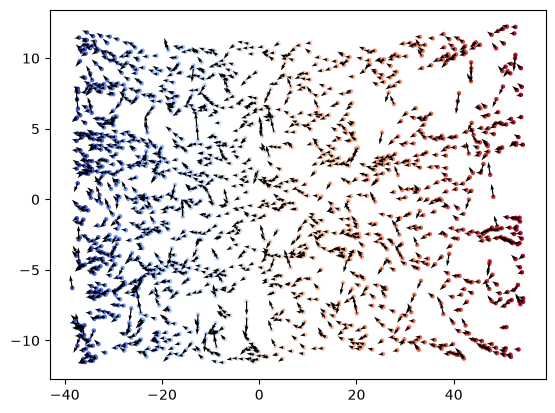

In [35]:
# Sort by x coords
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone()
unit_V_plt = unit_V[idx].clone()
t_plt = t[idx]
print(f"Number of non admissible points: {(~admissible).sum()}")
cbar = plt.scatter(
    X_low_plt[:, 0], X_low_plt[:, 1], c=t_plt, cmap="coolwarm",s=5
)
skip=1
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    unit_V_plt[::skip, 0],
    unit_V_plt[::skip, 1],
    color="black",
    scale=1,
    angles="xy",
    scale_units="xy",
)
# plt.colorbar(cbar, label="logdet(Gamma)")

In [36]:
V.shape
from torchvision.ops import MLP
# Train a NN to interpolate V
model = MLP(in_channels=2, hidden_channels=[64, 64,2])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_list = []
pbar = tqdm(range(1000))
for epoch in pbar:
    optimizer.zero_grad()
    V_pred = model(X_low)
    loss = torch.nn.functional.mse_loss(V_pred, V)
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Loss: {loss.item():.4f}")
    loss_list.append(loss.item())
# plt.plot(loss_list)

  0%|          | 0/1000 [00:00<?, ?it/s]

Loss: 9.3358: 100%|██████████| 1000/1000 [00:02<00:00, 451.90it/s]


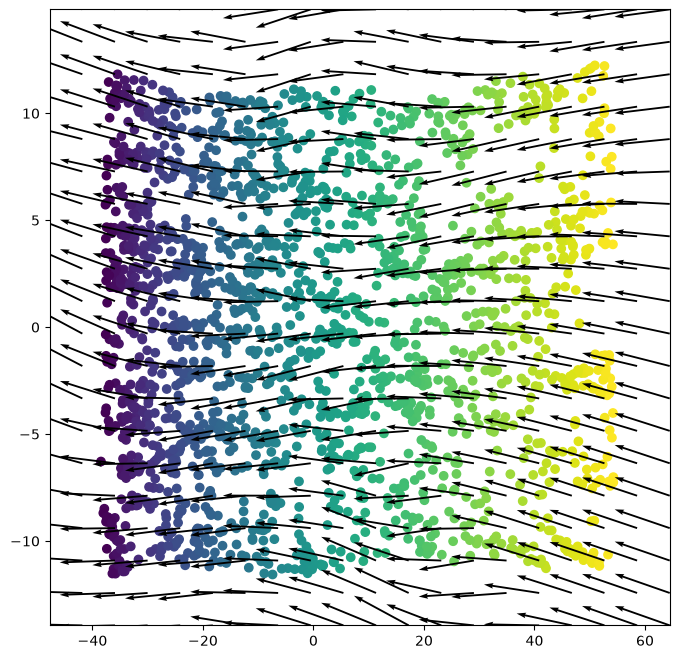

In [38]:
# Grid
x = torch.linspace(bounds[0], bounds[1], 20)
y = torch.linspace(bounds[2], bounds[3], 20)
X, Y = torch.meshgrid(x, y, indexing="ij")
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
V_grid = model(grid_points).detach()
V_grid_unit = V_grid / (V_grid.norm(dim=1, keepdim=True) + 1e-12)

plt.figure(figsize=(8, 8))
plt.scatter(X_low[:, 0], X_low[:, 1], c=t, cmap=plt.cm.viridis)
plt.quiver(
    grid_points[:, 0],
    grid_points[:, 1],
    V_grid_unit[:, 0],
    V_grid_unit[:, 1],
    color="black",
    scale=0.1,
    angles="xy",
    scale_units="xy",
)
plt.xlim(bounds[0], bounds[1])
plt.ylim(bounds[2], bounds[3])
# plt.tight_layout()
# plt.axis("equal")
plt.show()

# Old stuff

In [32]:
eigenvalues, eigenvectors = torch.linalg.eigh(L_theta_s)
K = 2
# X_low = eigenvectors[:, 1:K+1] * eigenvalues[:K]

X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform(W_theta_s.detach().cpu().numpy())
X_low = torch.from_numpy(X_low).float()


base_cometric_low = CentroidsCometric(centroids=X_low, cometric_centroids=IdentityCoMetric()(X_low))
base_cometric_low = IdentityCoMetric()

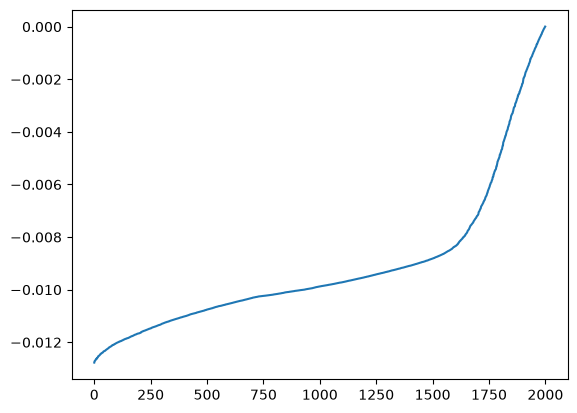

In [35]:
plt.plot(eigenvalues)

Text(0, 0.5, 'Y_low-axis')

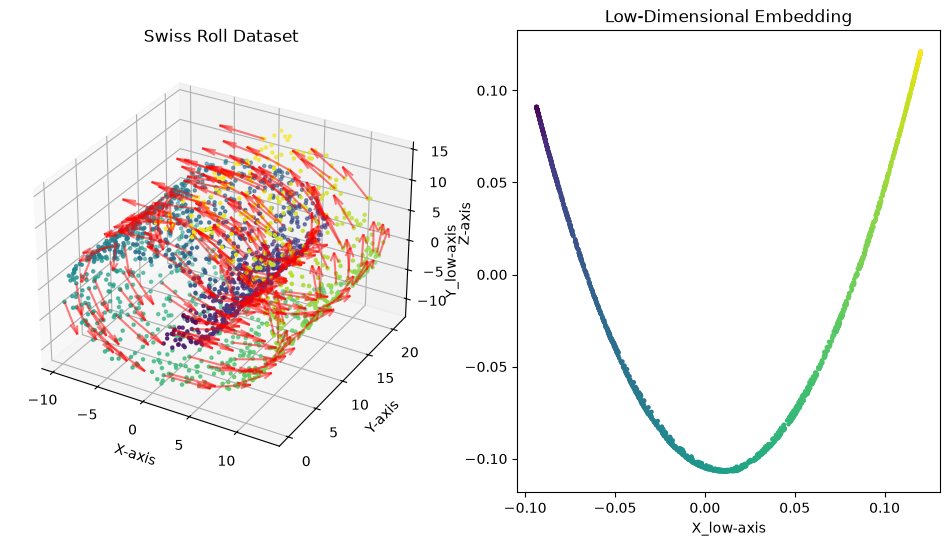

In [33]:
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax1.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           omega_x.detach()[::skip, 0], omega_x.detach()[::skip, 1], omega_x.detach()[::skip, 2],
           length=5, color='red', alpha=0.5)
           
ax1.set_title("Swiss Roll Dataset")
ax1.set_xlabel("X-axis")
ax1.set_ylabel("Y-axis")
ax1.set_zlabel("Z-axis")

ax2 = fig.add_subplot(122)
ax2.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1], c=t, cmap=plt.cm.viridis, s=5)
ax2.set_title("Low-Dimensional Embedding")
ax2.set_xlabel("X_low-axis")
ax2.set_ylabel("Y_low-axis")

[2026-09-17 15:24:15] - INFO - Training vector field models...


Loss: 2.5825e-05: 100%|██████████| 1000/1000 [00:02<00:00, 441.36it/s]


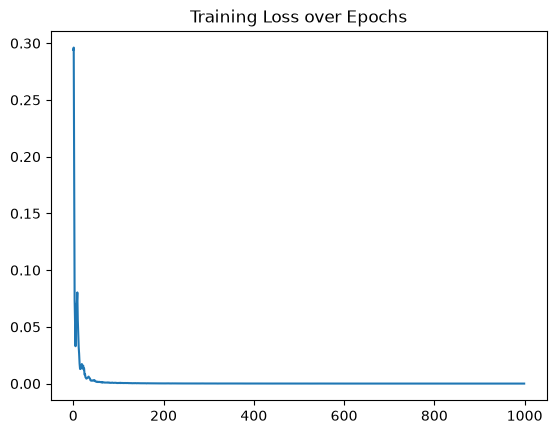

Relative Error (%) Statistics on the prediction of the operator:


{'mean': 2149.559814453125,
 'std': 13726.435546875,
 'min': 0.12001196295022964,
 'max': 479940.46875,
 'quantile_5': 24.230010986328125,
 'quantile_25': 139.57510375976562,
 'median': 372.6094665527344,
 'quantile_75': 978.0816040039062,
 'quantile_95': 5656.62353515625}

In [12]:
# High dim learning
f_values_high, Lf_values_high, f_grad_values_high = prepare_test_functions(
        K, function_type, X, L_theta_a
    )
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X, base_cometric, c_km, f_values_high, Lf_values_high, f_grad_values_high,m=3
)
v_hat_deep_high = v_model(X).detach()
b_hat_deep_high = omega_model(X).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

# Compute relative error:
rhs = c_km * torch.einsum('n d, k n d -> k n', v_hat_deep_high, f_grad_values_high)  # (1, N)
relative_error = torch.where(torch.abs(Lf_values_high) > 1e-8, torch.abs(Lf_values_high - rhs) / torch.abs(Lf_values_high) * 100, torch.zeros_like(Lf_values_high))
print(f"Relative Error (%) Statistics on the prediction of the operator:")
qqt_summary_statistics(relative_error.flatten())

In [13]:
b_norm = base_cometric.cometric(X, b_true).detach()
b_deep_high_norm = base_cometric.cometric(X, b_hat_deep_high).detach()
b_norm.mean(), b_deep_high_norm.mean(), b_deep_high_norm.std(), b_deep_high_norm.max()

(tensor(0.9000), tensor(0.0114), tensor(0.0062), tensor(0.0442))

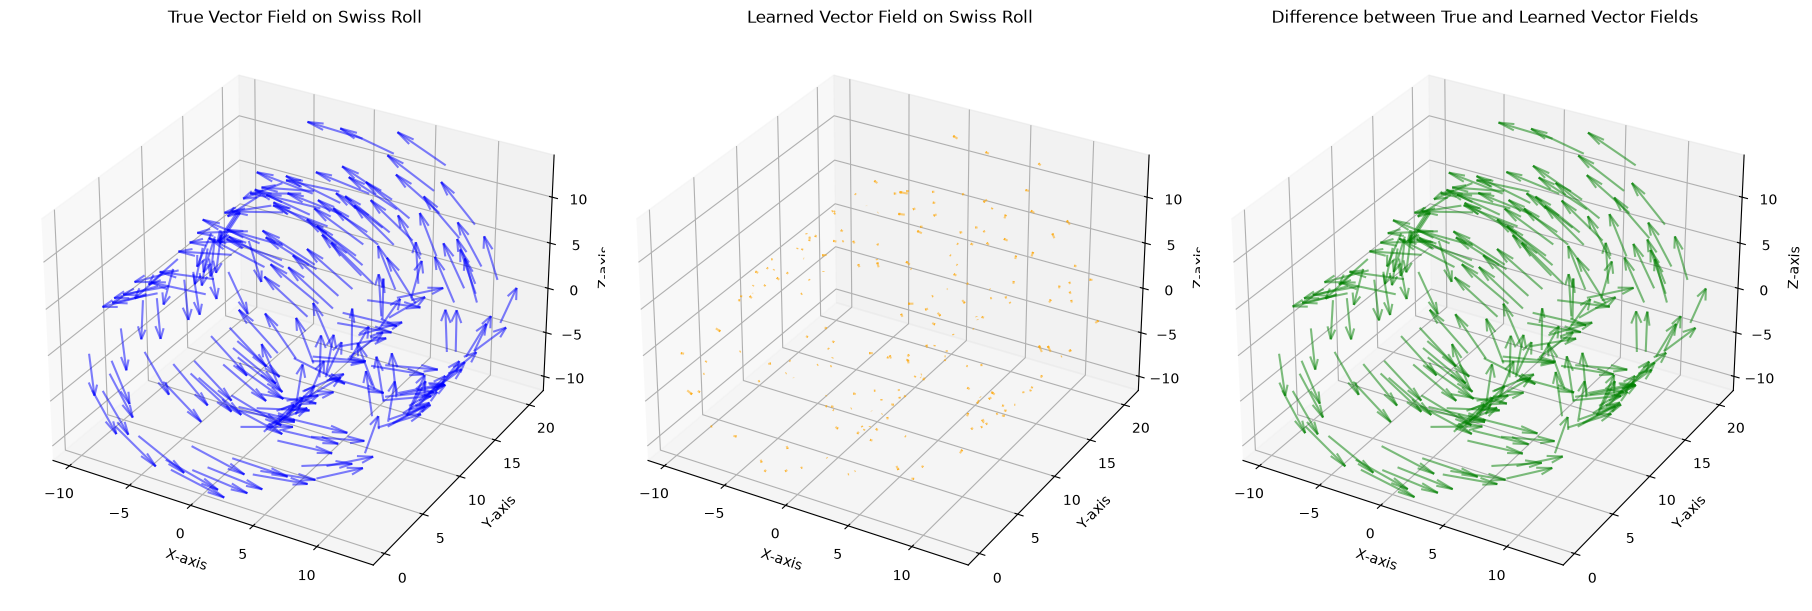

In [14]:
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
# ax1.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax1.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           b_true.detach()[::skip, 0], b_true.detach()[::skip, 1], b_true.detach()[::skip, 2],
           length=5, color='blue', alpha=0.5)
ax1.set_title("True Vector Field on Swiss Roll")

ax2 = fig.add_subplot(132, projection='3d')
# ax2.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax2.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           b_hat_deep_high[::skip, 0], b_hat_deep_high[::skip, 1], b_hat_deep_high[::skip, 2],
           length=20, color='orange', alpha=0.5)
ax2.set_title("Learned Vector Field on Swiss Roll")

delta_b = (b_true - b_hat_deep_high).detach()
ax3 = fig.add_subplot(133, projection='3d')
# ax3.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax3.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           delta_b[::skip, 0], delta_b[::skip, 1], delta_b[::skip, 2],
           length=5, color='green', alpha=0.5)
ax3.set_title("Difference between True and Learned Vector Fields")  

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")
    ax.set_zlabel("Z-axis")

plt.tight_layout()
plt.show()

# Low dim learning

In [15]:
f_values_low, Lf_values_low, f_grad_values_low = prepare_test_functions(
        K, function_type, X_low, L_theta_a
    )

[2026-09-17 15:24:19] - INFO - Training vector field models...


Loss: 8.1396e-09:  14%|█▍        | 145/1000 [00:00<00:01, 460.92it/s]

Loss: 4.8311e-09: 100%|██████████| 1000/1000 [00:02<00:00, 461.58it/s]


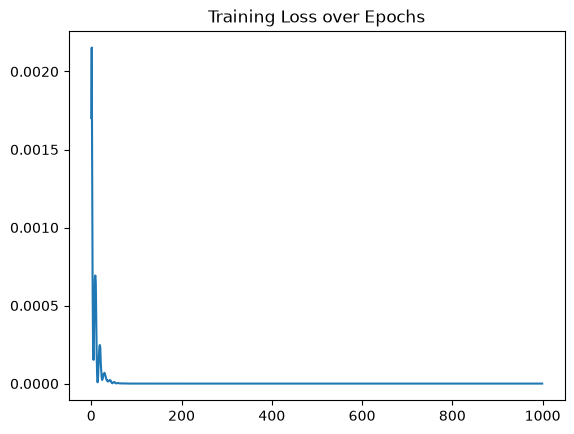

Relative Error (%) Statistics on the prediction of the operator:


{'mean': 3535.751708984375,
 'std': 18238.509765625,
 'min': 0.0,
 'max': 663799.5,
 'quantile_5': 23.743494033813477,
 'quantile_25': 201.67327880859375,
 'median': 811.6622924804688,
 'quantile_75': 2486.630126953125,
 'quantile_95': 10406.2724609375}

In [16]:
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X_low, base_cometric_low, c_km, f_values_low, Lf_values_low, f_grad_values_low
)
v_hat_deep_low = v_model(X_low).detach()
b_hat_deep_low = omega_model(X_low).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

# Compute relative error:
rhs = c_km * torch.einsum('n d, k n d -> k n', v_hat_deep_low, f_grad_values_low)  # (1, N)
relative_error = torch.where(torch.abs(Lf_values_low) > 1e-8, torch.abs(Lf_values_low - rhs) / torch.abs(Lf_values_low) * 100, torch.zeros_like(Lf_values_low))
print(f"Relative Error (%) Statistics on the prediction of the operator:")
qqt_summary_statistics(relative_error.flatten())

In [17]:
base_cometric_low.cometric(X_low,b_hat_deep_low).max() # Ptdr wtf

tensor(0.0004)

Text(0.5, 1.0, 'Learned Vector Field on Low-Dimensional Embedding')

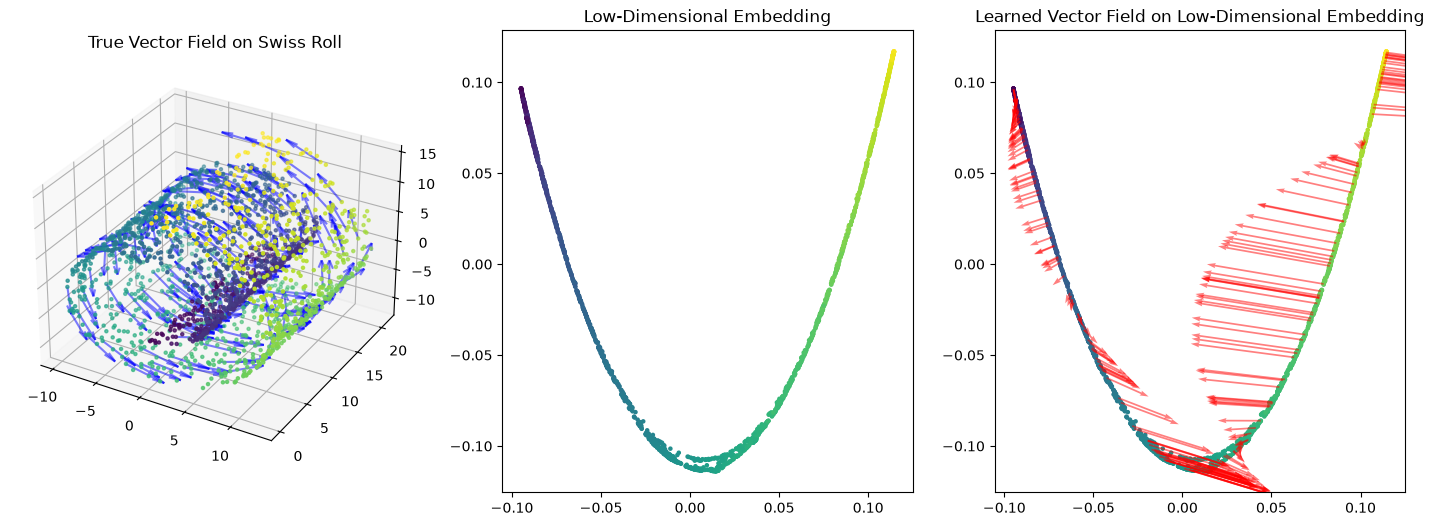

In [18]:
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax1.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           b_true.detach()[::skip, 0], b_true.detach()[::skip, 1], b_true.detach()[::skip, 2],
           length=5, color='blue', alpha=0.5)
ax1.set_title("True Vector Field on Swiss Roll")

ax2 = fig.add_subplot(132)
ax2.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1], c=t, cmap=plt.cm.viridis, s=5)
ax2.set_title("Low-Dimensional Embedding")

ax3 = fig.add_subplot(133)
ax3.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1], c=t, cmap=plt.cm.viridis, s=5)
ax3.quiver(X_low.detach()[::skip, 0], X_low.detach()[::skip, 1], 
           b_hat_deep_low[::skip, 0], b_hat_deep_low[::skip, 1],
           angles='xy', scale_units='xy', scale=0.004, color='red', alpha=0.5)
ax3.set_title("Learned Vector Field on Low-Dimensional Embedding")